In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import t
from statsmodels.graphics.tsaplots import plot_acf

In [3]:
bon = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/bonneville/bonneville.csv")
tda = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/dalles/dalles.csv")
jda = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/johnday/johnday.csv")
mcn = pd.read_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/mcnary/mcnary.csv")

In [4]:
bon_soc = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/US ACE Data 2026/bonneville-head.csv")
tda_soc = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/US ACE Data 2026/dalles-head.csv")
jda_soc = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/US ACE Data 2026/johnday-head.csv")
mcn_soc = pd.read_csv("/Users/elizacohn/Desktop/Columbia River Data/US ACE Data 2026/mcnary-head.csv")

bon_soc["Date Time"] = pd.to_datetime(bon_soc["Date Time"])
tda_soc["Date Time"] = pd.to_datetime(tda_soc["Date Time"])
jda_soc["Date Time"] = pd.to_datetime(jda_soc["Date Time"])
mcn_soc["Date Time"] = pd.to_datetime(mcn_soc["Date Time"])

# Calculate net elevation (head)
bon_soc["forebay_ft"] = bon_soc["BON.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"]
tda_soc["forebay_ft"] = tda_soc["TDA.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"]
jda_soc["forebay_ft"] = jda_soc["JDA.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"]
mcn_soc["forebay_ft"] = mcn_soc["MCN.Elev-Forebay.Inst.1Hour.0.CBT-REV [ft]"]

In [5]:
bon.rename(columns={"BON.Flow-Gen.Ave.1Hour.1Hour.CBT-REV [kcfs]": "outflow (kcfs)", "BON.Flow-In.Inst.~6Hours.0.RFC-FCST [kcfs]":"inflow (kcfs)",
                   "BON.Flow-Spill.Ave.1Hour.1Hour.CBT-REV [kcfs]":"spill (kcfs)"}, inplace=True)
tda.rename(columns={"TDA.Flow-Gen.Ave.1Hour.1Hour.CBT-REV [kcfs]": "outflow (kcfs)", "TDA.Flow-In.Inst.~6Hours.0.RFC-FCST [kcfs]":"inflow (kcfs)",
                   "TDA.Flow-Spill.Ave.1Hour.1Hour.CBT-REV [kcfs]":"spill (kcfs)"}, inplace=True)
jda.rename(columns={"JDA.Flow-Gen.Ave.1Hour.1Hour.CBT-REV [kcfs]": "outflow (kcfs)", "JDA.Flow-In.Inst.~6Hours.0.RFC-FCST [kcfs]":"inflow (kcfs)",
                   "JDA.Flow-Spill.Ave.1Hour.1Hour.CBT-REV [kcfs]":"spill (kcfs)"}, inplace=True)
mcn.rename(columns={"MCN.Flow-Gen.Ave.1Hour.1Hour.CBT-REV [kcfs]": "outflow (kcfs)", "MCN.Flow-In.Inst.~6Hours.0.RFC-FCST [kcfs]":"inflow (kcfs)",
                   "MCN.Flow-Spill.Ave.1Hour.1Hour.CBT-REV [kcfs]":"spill (kcfs)"}, inplace=True)

In [6]:
soc_df = (
    bon_soc[["Date Time", "forebay_ft"]]
    .rename(columns={"forebay_ft": "bon_forebay_ft"})
    .merge(
        tda_soc[["Date Time", "forebay_ft"]]
        .rename(columns={"forebay_ft": "tda_forebay_ft"}),
        on="Date Time",
        how="inner",
    )
    .merge(
        jda_soc[["Date Time", "forebay_ft"]]
        .rename(columns={"forebay_ft": "jda_forebay_ft"}),
        on="Date Time",
        how="inner",
    )
    .merge(
        mcn_soc[["Date Time", "forebay_ft"]]
        .rename(columns={"forebay_ft": "mcn_forebay_ft"}),
        on="Date Time",
        how="inner",
    )
)

In [7]:
# Backfill 6-hr streamflow data
bon = bon.bfill()
tda = tda.bfill()
jda = jda.bfill()
mcn = mcn.bfill()

In [8]:
dfs = {
    "bon": bon,
    "tda": tda,
    "jda": jda,
    "mcn": mcn,
}

## System Parameters

In [10]:
def flow_limits(dfs, flow_col="outflow (kcfs)"):
    rows = []
    for name, df in dfs.items():
        x = df[flow_col].dropna()
        ramp = x.diff().dropna()
        rows.append({"unit": name, "min_flow_kcfs": x.min(), "max_flow_kcfs": x.max(), "min_ramp_kcfs_per_hr": ramp.min(), "max_ramp_kcfs_per_hr": ramp.max()})
    return pd.DataFrame(rows)

In [11]:
dfs = {"bon": bon, "tda": tda, "jda": jda, "mcn": mcn}
limits = flow_limits(dfs, flow_col="outflow (kcfs)")
print(limits)

  unit  min_flow_kcfs  max_flow_kcfs  min_ramp_kcfs_per_hr  \
0  bon           29.0          260.0                -120.6   
1  tda           23.4          268.3                -118.1   
2  jda           47.5          265.4                -133.7   
3  mcn            0.0          230.8                 -94.6   

   max_ramp_kcfs_per_hr  
0                  68.7  
1                 110.2  
2                 135.0  
3                  94.6  


## Hydrograph

In [13]:
flow_dfs = [
    df[["Date Time", "inflow (kcfs)"]]
      .rename(columns={"inflow (kcfs)": f"{name}_inflow_kcfs"})
    for name, df in dfs.items()
]

hydrograph_df = (
    bon[["Date Time", "inflow (kcfs)"]]
    .rename(columns={"inflow (kcfs)": "bon_inflow_kcfs"})
    .merge(
        tda[["Date Time", "inflow (kcfs)"]]
        .rename(columns={"inflow (kcfs)": "tda_inflow_kcfs"}),
        on="Date Time",
        how="inner",
    )
    .merge(
        jda[["Date Time", "inflow (kcfs)"]]
        .rename(columns={"inflow (kcfs)": "jda_inflow_kcfs"}),
        on="Date Time",
        how="inner",
    )
    .merge(
        mcn[["Date Time", "inflow (kcfs)"]]
        .rename(columns={"inflow (kcfs)": "mcn_inflow_kcfs"}),
        on="Date Time",
        how="inner",
    )
)

In [14]:
inflow_cols = [
    "bon_inflow_kcfs",
    "tda_inflow_kcfs",
    "jda_inflow_kcfs",
    "mcn_inflow_kcfs",
]

kcfs_to_m3s = 28.316846592

hydrograph_df["mean_inflow_m3s"] = hydrograph_df[inflow_cols].mean(axis=1) * kcfs_to_m3s

hydrograph_df["Date Time"] = pd.to_datetime(hydrograph_df["Date Time"])

hydrograph_df = hydrograph_df[hydrograph_df["Date Time"] >= "2018-01-01"].copy()

In [15]:
hydrograph_df.head()

,Date Time,bon_inflow_kcfs,tda_inflow_kcfs,jda_inflow_kcfs,mcn_inflow_kcfs,mean_inflow_m3s
4,2018-01-01 00:00:00,184.574,179.31,176.265,171.521,5038.062554
5,2018-01-01 01:00:00,184.574,179.31,176.265,171.521,5038.062554
6,2018-01-01 02:00:00,184.574,179.31,176.265,171.521,5038.062554
7,2018-01-01 03:00:00,184.574,179.31,176.265,171.521,5038.062554
8,2018-01-01 04:00:00,184.574,179.31,176.265,171.521,5038.062554


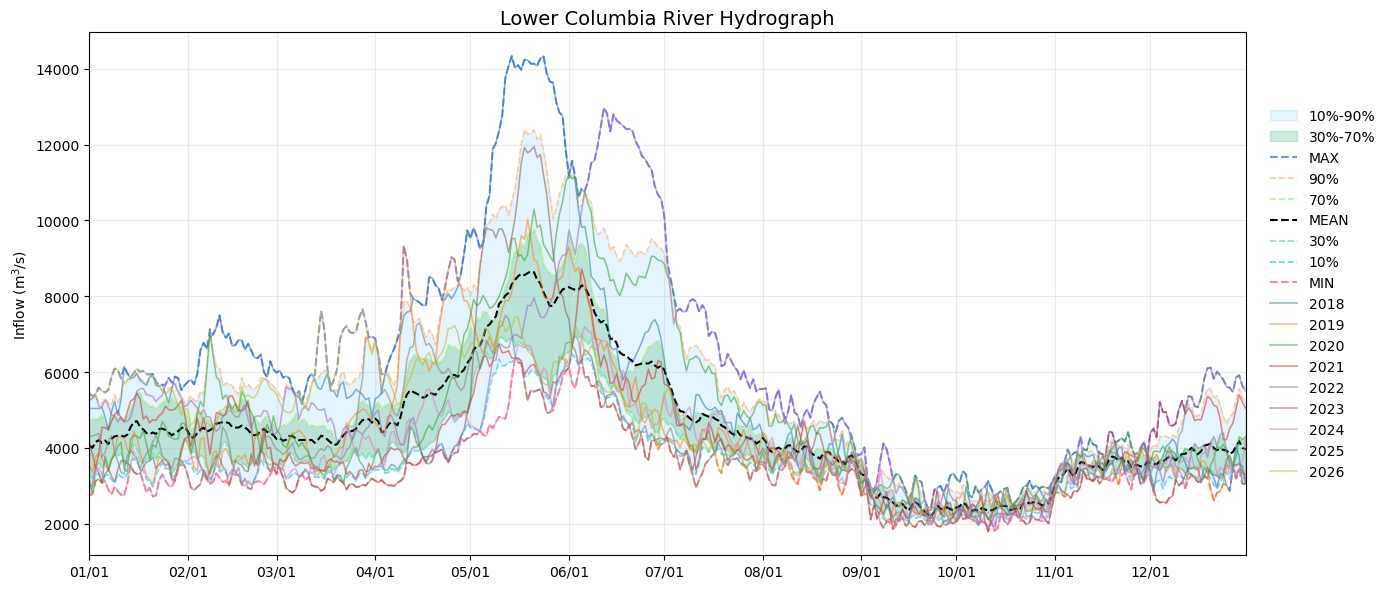

In [16]:
import matplotlib.dates as mdates

plot_individual_years = True # Toggle: True = show yearly lines, False = hide them

df = hydrograph_df.copy()

df["Date Time"] = pd.to_datetime(df["Date Time"])
df = df[df["Date Time"] >= "2018-01-01"].copy()

df["year"] = df["Date Time"].dt.year
df["month"] = df["Date Time"].dt.month
df["day"] = df["Date Time"].dt.day

# Remove leap day so every year maps cleanly onto Jan 1-Dec 31
df = df[~((df["month"] == 2) & (df["day"] == 29))].copy()

# Use a common non-leap year for plotting all years on the same Jan-Dec axis
df["plot_date"] = pd.to_datetime(
    {
        "year": 2023,
        "month": df["month"],
        "day": df["day"],
    }
)

df = df.dropna(subset=["plot_date", "mean_inflow_m3s"])

# Daily average in case your data are hourly/subdaily
daily = (
    df.groupby(["year", "plot_date"], as_index=False)["mean_inflow_m3s"]
    .mean()
)

stats = (
    daily.groupby("plot_date")["mean_inflow_m3s"]
    .agg(
        min_flow="min",
        mean_flow="mean",
        max_flow="max",
        q10=lambda x: x.quantile(0.10),
        q30=lambda x: x.quantile(0.30),
        q70=lambda x: x.quantile(0.70),
        q90=lambda x: x.quantile(0.90),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

# Shaded quantile bands
ax.fill_between(
    stats["plot_date"],
    stats["q10"],
    stats["q90"],
    color="lightskyblue",
    alpha=0.22,
    label="10%-90%",
)

ax.fill_between(
    stats["plot_date"],
    stats["q30"],
    stats["q70"],
    color="mediumseagreen",
    alpha=0.25,
    label="30%-70%",
)

# Summary statistics
ax.plot(stats["plot_date"], stats["max_flow"], color="#7b8cff", linestyle="--", linewidth=1.5, label="MAX")
ax.plot(stats["plot_date"], stats["q90"], color="#ffcc99", linestyle="--", linewidth=1.2, label="90%")
ax.plot(stats["plot_date"], stats["q70"], color="#b9f59b", linestyle="--", linewidth=1.2, label="70%")
ax.plot(stats["plot_date"], stats["mean_flow"], color="black", linestyle="--", linewidth=1.5, label="MEAN")
ax.plot(stats["plot_date"], stats["q30"], color="#7ee6b8", linestyle="--", linewidth=1.2, label="30%")
ax.plot(stats["plot_date"], stats["q10"], color="#66d9ff", linestyle="--", linewidth=1.2, label="10%")
ax.plot(stats["plot_date"], stats["min_flow"], color="#ff8f8f", linestyle="--", linewidth=1.5, label="MIN")

# Optional individual yearly hydrographs
if plot_individual_years:
    for year, group in daily.groupby("year"):
        ax.plot(
            group["plot_date"],
            group["mean_inflow_m3s"],
            linewidth=1.1,
            alpha=0.55,
            label=str(year),
        )

ax.set_title("Lower Columbia River Hydrograph", fontsize=14)
ax.set_ylabel("Inflow (m$^3$/s)")
ax.set_xlabel("")

ax.set_xlim(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31"))

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))

ax.grid(True, alpha=0.25)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)

plt.tight_layout()
plt.show()

## Dry Season Analysis

In [18]:
df = tda.copy()

df["Date Time"] = pd.to_datetime(df["Date Time"])
df = df.sort_values("Date Time").copy()
df = df[df["Date Time"] >= "2018-01-01"]

spill_col = "spill (kcfs)"  

# Smooth the time series rolling window
window = 14*24  # active window
min_spill_days = 7*24

df["spill_days_rolling"] = (
    df[spill_col]
    .rolling(window=window, center=True, min_periods=1)
    .sum()
)

# Minimum days of spill 
df["spill_active_smooth"] = df["spill_days_rolling"] >= min_spill_days

# Define dry season as smoothed no-spill periods
df["dry_season"] = ~df["spill_active_smooth"]

In [19]:
df.head()

,Date Time,outflow (kcfs),inflow (kcfs),spill (kcfs),spill_days_rolling,spill_active_smooth,dry_season
4,2018-01-01 00:00:00,148.4,179.31,0.0,0.0,False,True
5,2018-01-01 01:00:00,123.9,179.31,0.0,0.0,False,True
6,2018-01-01 02:00:00,121.1,179.31,0.0,0.0,False,True
7,2018-01-01 03:00:00,121.9,179.31,0.0,0.0,False,True
8,2018-01-01 04:00:00,121.6,179.31,0.0,0.0,False,True


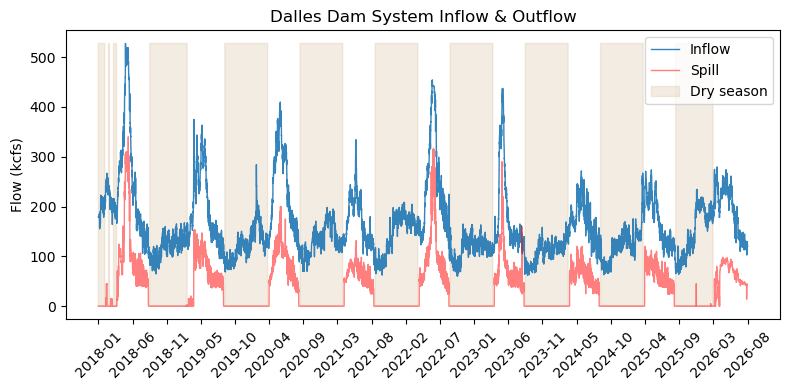

In [20]:
plt.figure(figsize=(8, 4))

tick_idx = np.linspace(0, len(df)-1, 20).astype(int)
#plt.plot(df["Date Time"], df["outflow (kcfs)"], linewidth=1, label="Gen. Outflow", color="green", alpha = 0.5)
plt.plot(df["Date Time"], df["inflow (kcfs)"], linewidth=1, label="Inflow", alpha = 0.9)
plt.plot(df["Date Time"], df[spill_col], linewidth=1, label="Spill", color = "red", alpha = 0.5)

plt.fill_between(df["Date Time"], 0, df["inflow (kcfs)"].max(), where=df["dry_season"], color="tan", alpha=0.25, label="Dry season")
plt.xticks(df["Date Time"].iloc[tick_idx], df["Date Time"].iloc[tick_idx].dt.strftime("%Y-%m"), rotation=45)

plt.ylabel("Flow (kcfs)")
plt.title("Dalles Dam System Inflow & Outflow")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
dry_blocks = df[df["dry_season"]].copy()
dry_blocks["block"] = (dry_blocks["Date Time"].diff() > pd.Timedelta(hours=1)).cumsum()
dry_ranges = dry_blocks.groupby("block")["Date Time"].agg(["min", "max"])
dry_ranges["days"] = (dry_ranges["max"] - dry_ranges["min"]).dt.days
dry_ranges = dry_ranges[dry_ranges["days"] >= 40]

print("Dry season training date ranges:")
for _, row in dry_ranges.iterrows(): print(f"{row['min'].strftime('%Y-%m-%d')} to {row['max'].strftime('%Y-%m-%d')}")

Dry season training date ranges:
2018-09-07 to 2018-11-26
2018-11-26 to 2019-03-08
2019-09-07 to 2020-04-03
2020-09-07 to 2021-04-03
2021-09-07 to 2022-04-03
2022-09-07 to 2022-11-09
2022-11-10 to 2023-04-03
2023-10-17 to 2024-03-18
2024-09-07 to 2025-04-03
2025-09-07 to 2026-03-08


### Rank Driest Year

In [23]:
flow_col = "mean_inflow_m3s"
df_flow = hydrograph_df.copy()
df_flow["Date Time"] = pd.to_datetime(df_flow["Date Time"])
dry_90_flow = df_flow[((df_flow["Date Time"].dt.month == 9) & (df_flow["Date Time"].dt.day >= 7)) | (df_flow["Date Time"].dt.month.isin([10, 11])) | ((df_flow["Date Time"].dt.month == 12) & (df_flow["Date Time"].dt.day <= 5))].copy()
dry_90_flow["dry_year"] = dry_90_flow["Date Time"].dt.year
dry_rank = dry_90_flow.groupby("dry_year")[flow_col].agg(["mean", "min", "max"]).sort_values("mean")
print(dry_rank)

                 mean          min          max
dry_year                                       
2023      2620.814712  1714.839913  4382.053248
2024      2721.669141  1751.984536  3851.954800
2019      2821.764159  1931.669086  4220.222469
2025      2856.971135  1774.149548  4309.710784
2021      2886.486209  1739.234876  5549.910793
2022      2917.205257  1680.116380  4584.476226
2018      2934.280913  1812.731251  4429.682184
2020      3208.168699  1928.681659  4896.180994


### Plot Streamflow Scenarios

In [25]:
# Copy over streamflow data
save_df = hydrograph_df[((hydrograph_df["Date Time"].dt.month == 9) & (hydrograph_df["Date Time"].dt.day >= 7)) | (hydrograph_df["Date Time"].dt.month.isin([10, 11])) | ((hydrograph_df["Date Time"].dt.month == 12) & (hydrograph_df["Date Time"].dt.day <= 5))].copy()
inflow_data = save_df.drop(columns="mean_inflow_m3s").copy() 

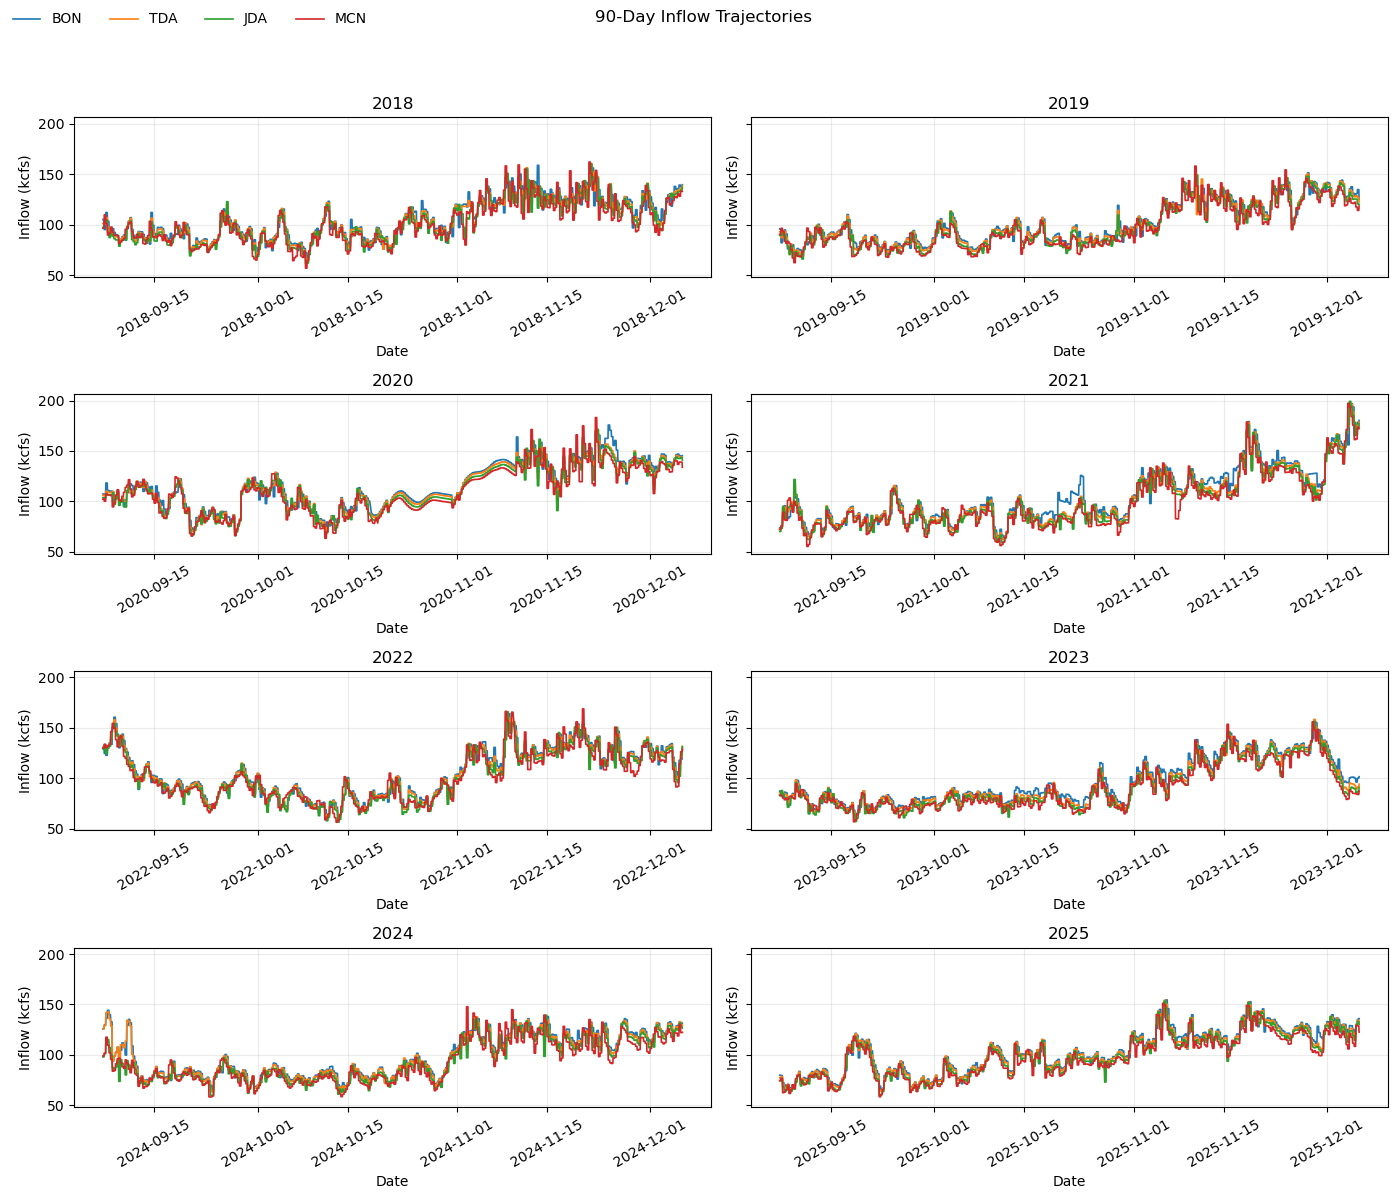

In [26]:
# Remove "_kcfs" from column names
inflow_data = inflow_data.rename(columns=lambda col: col.replace("_kcfs", ""))

# Ensure Date Time is datetime
inflow_data["Date Time"] = pd.to_datetime(inflow_data["Date Time"])
inflow_cols = ["bon_inflow", "tda_inflow", "jda_inflow","mcn_inflow"]

# Extract scenario years
years = sorted(inflow_data["Date Time"].dt.year.unique())

# Begin plotting figure
fig, axes = plt.subplots( 4, 2,figsize=(14, 12), sharey=True)

axes = axes.flatten()

for ax, year in zip(axes, years):
    # Extract scenario year
    df_year = inflow_data[inflow_data["Date Time"].dt.year == year]

    for col in inflow_cols:
        ax.plot(
            df_year["Date Time"],
            df_year[col],
            label=col.replace("_inflow", "").upper(),
            linewidth=1.2
        )

    ax.set_title(str(year))
    ax.set_xlabel("Date")
    ax.set_ylabel("Inflow (kcfs)")
    ax.grid(alpha=0.25)
    ax.tick_params(axis="x", rotation=30)

# Use one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", ncol=4,frameon=False)

fig.suptitle("90-Day Inflow Trajectories", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [27]:
inflow_data = inflow_data.rename(columns={"Date Time": "datetime"}) 

### Find Missing Dates and Interpolate 

In [29]:
len(inflow_data) # should be 17280 

17224

In [30]:
years = range(2018, 2026)  # Complete seasons: 2018-2025

# Expected hourly timestamps
expected = pd.DatetimeIndex([]).append([pd.date_range(f"{y}-09-07", f"{y}-12-05 23:00", freq="h") for y in years])

In [31]:
expected

DatetimeIndex(['2018-09-07 00:00:00', '2018-09-07 01:00:00',
               '2018-09-07 02:00:00', '2018-09-07 03:00:00',
               '2018-09-07 04:00:00', '2018-09-07 05:00:00',
               '2018-09-07 06:00:00', '2018-09-07 07:00:00',
               '2018-09-07 08:00:00', '2018-09-07 09:00:00',
               ...
               '2025-12-05 14:00:00', '2025-12-05 15:00:00',
               '2025-12-05 16:00:00', '2025-12-05 17:00:00',
               '2025-12-05 18:00:00', '2025-12-05 19:00:00',
               '2025-12-05 20:00:00', '2025-12-05 21:00:00',
               '2025-12-05 22:00:00', '2025-12-05 23:00:00'],
              dtype='datetime64[ns]', length=17280, freq=None)

In [32]:
# Check missing timestamps
missing = expected.difference(inflow_data["datetime"])
print("Missing hours by year:")
print(pd.Series(missing.year).value_counts().sort_index())

Missing hours by year:
2018     3
2019     1
2020    26
2021     4
2022    20
2023     2
Name: count, dtype: int64


In [33]:
# Remove duplicate timestamps and add missing rows
inflow_data = (
    inflow_data.groupby("datetime", as_index=False)[inflow_cols]
    .mean()
    .set_index("datetime")
    .reindex(expected)
)

In [34]:
# Print missing data
print(inflow_data.shape)     
print(inflow_data.isna().sum())

(17280, 4)
bon_inflow    56
tda_inflow    56
jda_inflow    56
mcn_inflow    56
dtype: int64


In [35]:
# Interpolate data
inflow_data[inflow_cols] = inflow_data[inflow_cols].bfill()

inflow_data = inflow_data.reset_index(names="datetime")

print(inflow_data.shape)     
print(inflow_data.isna().sum())

(17280, 5)
datetime      0
bon_inflow    0
tda_inflow    0
jda_inflow    0
mcn_inflow    0
dtype: int64


In [36]:
# Save data
inflow_data.to_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/inflow-6hr.csv", index=False)

In [37]:
inflow_data.head()

,datetime,bon_inflow,tda_inflow,jda_inflow,mcn_inflow
0,2018-09-07 00:00:00,105.091,101.074,97.247,96.451
1,2018-09-07 01:00:00,105.091,101.074,97.247,96.451
2,2018-09-07 02:00:00,105.091,101.074,97.247,96.451
3,2018-09-07 03:00:00,105.091,101.074,97.247,96.451
4,2018-09-07 04:00:00,105.091,101.074,97.247,96.451


# Reconstruct Hourly Streamflow Data

In [39]:
soc_df = soc_df.rename(columns={"Date Time": "datetime"})
soc_df["datetime"] = pd.to_datetime(soc_df["datetime"])
soc_df = soc_df[(soc_df["datetime"] >= "2018-09-07") & (soc_df["datetime"] < "2025-12-06")].reset_index(drop=True)

In [40]:
soc_df.head()

,datetime,bon_forebay_ft,tda_forebay_ft,jda_forebay_ft,mcn_forebay_ft
0,2018-09-07 00:00:00,74.8,159.0,263.31,338.89
1,2018-09-07 01:00:00,74.9,159.0,263.31,339.04
2,2018-09-07 02:00:00,74.9,159.0,263.41,339.10
3,2018-09-07 03:00:00,74.7,159.0,263.41,339.19
4,2018-09-07 04:00:00,74.9,159.0,263.41,339.25


In [41]:
# Load reservoir outflow data (kcfs)
outflow = pd.DataFrame()

outflow["datetime"] = bon["Date Time"]
outflow["bon_outflow"] = bon["outflow (kcfs)"]
outflow["tda_outflow"] = tda["outflow (kcfs)"]
outflow["jda_outflow"] = jda["outflow (kcfs)"]
outflow["mcn_outflow"] = mcn["outflow (kcfs)"]

In [42]:
# Find missing data and backfill 
outflow["datetime"] = pd.to_datetime(outflow["datetime"])

outflow = (
    outflow.set_index("datetime")
           .reindex(expected)
           .bfill()
           .reset_index(names="datetime")
)

In [43]:
outflow.head()

,datetime,bon_outflow,tda_outflow,jda_outflow,mcn_outflow
0,2018-09-07 00:00:00,85.2,67.8,73.5,67.8
1,2018-09-07 01:00:00,76.3,62.8,69.4,65.0
2,2018-09-07 02:00:00,75.5,63.0,69.9,63.8
3,2018-09-07 03:00:00,73.5,64.9,71.4,74.3
4,2018-09-07 04:00:00,73.2,72.6,77.8,83.9


In [44]:
# Make save dataframe

K = 0.0826446  # kaf per kcfs-hour
units = ["bon", "tda", "jda", "mcn"]

# Your fitted equations: H_norm = a * V_norm + b
fit = {
    "bon": (0.85, 0.08),
    "tda": (0.73, 0.21),
    "jda": (0.83, 0.12),
    "mcn": (1.0, 0.0),
}

df = outflow.merge(soc_df, on="datetime", how="inner")

recon = pd.DataFrame({"datetime": df["datetime"]})


In [45]:
for u in units:
    a, b = fit[u]

    # 1. Normalize observed forebay from ft to [0, 1] per unit
    H_ft = df[f"{u}_forebay_ft"]
    H_norm = (H_ft - H_ft.min()) / (H_ft.max() - H_ft.min())

    # 2. Convert norm head to norm volume using inverse head function
    V_norm = np.clip((H_norm - b) / a, 0, 1)

    # 3. Convert normalized volume to physical storage in kaf
    V_kaf = V_norm.min() + V_norm * (V_norm.max() - V_norm.min())

    # 4. Calculate (A) change on storage and (B) mass balance
    dV_kaf = V_kaf.diff()
    O_kcfs = df[f"{u}_outflow"]

    # v_t = v_t-1 + inlow_t - outflow_t
    recon[f"{u}_inflow_recon"] = O_kcfs + dV_kaf / K

In [46]:
def pred_error(df1, df2, units, y_suffix="_inflow", yhat_suffix="_inflow_recon"):
    rows = []

    for u in units:
        y = df1[f"{u}{y_suffix}"]
        yhat = df2[f"{u}{yhat_suffix}"]

        mask = np.isfinite(y) & np.isfinite(yhat)

        err = yhat[mask] - y[mask]

        rows.append({
            "unit": u,
            "rmse": np.sqrt(np.mean(err**2)),
            "bias": np.mean(err),
            "corr": np.corrcoef(y[mask], yhat[mask])[0, 1],
        })

    return pd.DataFrame(rows)

In [47]:
recon.head()

,datetime,bon_inflow_recon,tda_inflow_recon,jda_inflow_recon,mcn_inflow_recon
0,2018-09-07 00:00:00,NaN,NaN,NaN,NaN
1,2018-09-07 01:00:00,76.602879,62.8,69.400000,65.674721
2,2018-09-07 02:00:00,75.500000,63.0,70.326267,64.069889
3,2018-09-07 03:00:00,72.894243,64.9,71.400000,74.704833
4,2018-09-07 04:00:00,73.805757,72.6,77.800000,84.169889


In [48]:
compare = recon.merge(inflow_data, on="datetime", how="inner")

# Add shifted bias to streamflow reconstruction
for u in units:
    bias = np.mean(compare[f"{u}_inflow_recon"] - compare[f"{u}_inflow"])
    recon[f"{u}_inflow_recon_bc"] = recon[f"{u}_inflow_recon"] - bias

In [49]:
# Apply rolling average to output
window = 1   # hours; change to 6, 12, etc. if wanted

for u in units:
    col = f"{u}_inflow_recon_bc"
    recon[f"{u}_inflow_avg"] = (
        recon[col]
        .rolling(window=window, min_periods=1, center=False)
        .median()
    )

In [50]:
# Calculate prediction error for EC rolling average
pred_error(compare, recon, units, "_inflow","_inflow_recon_bc")


,unit,rmse,bias,corr
0,bon,14.490493,-1.691198e-15,0.819479
1,tda,21.047129,4.095871e-16,0.676763
2,jda,20.022646,2.483947e-15,0.701621
3,mcn,21.636856,3.910896e-15,0.656569


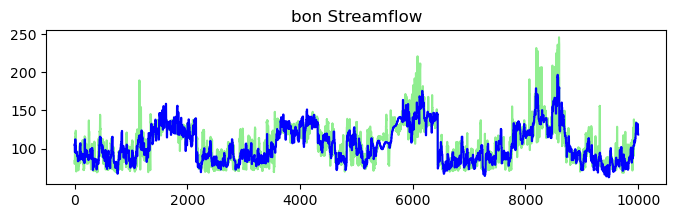

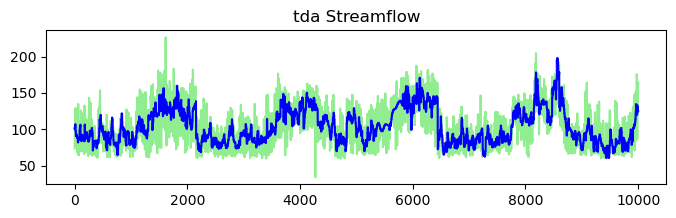

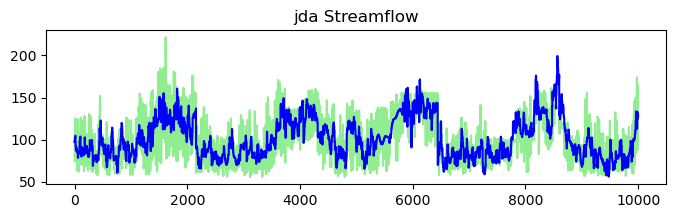

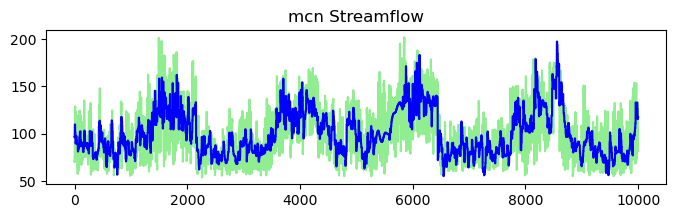

In [51]:
for u in units:
    T = 10000
    plt.figure(figsize=(8, 2))
    plt.plot(recon[f"{u}_inflow_avg"].iloc[0:T], label = "Reconstructed (1 hr)", color="lightgreen")
    plt.plot(compare[f"{u}_inflow"].iloc[0:T], label = "Ground Truth (6hr)", color="blue")
    # Ning reconstruct: Check indexing same time steps 
    # plt.plot(ref_subset[f"{u}_inflow"].iloc[0:T], label = "Ning Reconstructed")
    plt.title(f"{u} Streamflow")
    # plt.legend()
    plt.show()


In [52]:
units = ["bon", "tda", "jda", "mcn"]

rename_cols = {
    f"{u}_inflow_recon_bc": f"{u}_inflow"
    for u in units
}

inflow_hourly = (
    recon[["datetime", *rename_cols]]
    .rename(columns=rename_cols)
    .copy()
)

# Fill the initial NaN created by diff()
inflow_hourly[[f"{u}_inflow" for u in units]] = (inflow_hourly[[f"{u}_inflow" for u in units]].bfill())

inflow_hourly.to_csv("/Users/elizacohn/Desktop/cascaded-hydro/simulation-data/inflow-hourly.csv", index=False)

inflow_hourly.head()

,datetime,bon_inflow,tda_inflow,jda_inflow,mcn_inflow
0,2018-09-07 00:00:00,83.458768,73.443337,74.289808,71.536267
1,2018-09-07 01:00:00,83.458768,73.443337,74.289808,71.536267
2,2018-09-07 02:00:00,82.355889,73.643337,75.216074,69.931434
3,2018-09-07 03:00:00,79.750132,75.543337,76.289808,80.566379
4,2018-09-07 04:00:00,80.661647,83.243337,82.689808,90.031434


# Estimate Travel Times

In [54]:
reaches = [
    ("mcn", "jda", 85), # miles between each unit 
    ("jda", "tda", 25),
    ("tda", "bon", 40),
]

vmin, vmax = 5, 20   # plausible river travel speed, miles/hour

q = recon.merge(outflow, on="datetime")
rows = []

for up, down, miles in reaches:
    lags = range(max(1, int(np.ceil(miles / vmax))),
                 int(np.floor(miles / vmin)) + 1)

    x = q[f"{up}_outflow"]
    y = q[f"{down}_inflow_avg"]

    corrs = [x.shift(h).corr(y) for h in lags]
    h = list(lags)[np.nanargmax(corrs)]

    rows.append({
        "reach": f"{up} → {down}",
        "miles": miles,
        "travel_time_hr": h,
        "speed_mph": miles / h,
        "corr": max(corrs),
    })

travel_time = pd.DataFrame(rows)
travel_time

,reach,miles,travel_time_hr,speed_mph,corr
0,mcn → jda,85,10,8.5,0.667360
1,jda → tda,25,2,12.5,0.757680
2,tda → bon,40,4,10.0,0.727893


# Inflow Forecasting

In [56]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [57]:
train_years = [2018, 2019, 2020, 2021, 2022]
test_years  = [2023, 2024, 2025]

In [58]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.metrics import r2_score
from statsmodels.graphics.tsaplots import plot_acf


def diagnose(result, unit, nlags=48):
    data = result[["actual", "predicted"]].dropna().sort_index()
    fitted = data["predicted"]
    residuals = data["actual"] - fitted

    print(f"{unit.upper()} test R²: "
          f"{r2_score(data['actual'], fitted):.3f}")

    fig, ax = plt.subplots(2, 2, figsize=(10, 7))

    ax[0, 0].scatter(fitted, residuals, s=8, alpha=0.4)
    ax[0, 0].axhline(0, color="black")
    ax[0, 0].set(
        title="Fitted vs residuals",
        xlabel="Predicted",
        ylabel="Residual",
    )

    ax[0, 1].hist(residuals, bins=40)
    ax[0, 1].set(
        title="Residual histogram",
        xlabel="Residual",
    )

    plot_acf(
        residuals,
        lags=min(nlags, len(residuals) - 1),
        ax=ax[1, 0],
    )

    sm.qqplot(residuals, line="s", ax=ax[1, 1])
    ax[1, 1].set_title("Normal Q-Q plot")

    fig.suptitle(unit.upper())
    plt.tight_layout()
    plt.show()

## Data Preprocessing

In [126]:
def add_season_year(df):
    df = df.copy()
    dt = pd.to_datetime(df["datetime"])
    df["season_year"] = dt.dt.year - (dt.dt.month <= 4)
    return df

In [234]:
# Feature map (not predicting mcnary since no upstream relesae)
reach_map = {
    "jda": ("jda_inflow_avg", "mcn_outflow", 24, [9, 10, 11]),
    "tda": ("tda_inflow_avg", "jda_outflow", 24, [1, 2, 3]),
    "bon": ("bon_inflow_avg", "tda_outflow", 24, [3, 4, 5]),
}

model_df = (
    recon[["datetime","bon_inflow_avg","tda_inflow_avg", "jda_inflow_avg","mcn_inflow_avg"]]
    .merge(outflow[["datetime","tda_outflow","jda_outflow","mcn_outflow",]],on="datetime", how="inner",
    ).sort_values("datetime").reset_index(drop=True)
)

# Tag data year 
model_df = model_df.bfill()
model_df["datetime"] = pd.to_datetime(model_df["datetime"])
model_df = add_season_year(model_df)

In [238]:
model_df.head()

,datetime,bon_inflow_avg,tda_inflow_avg,jda_inflow_avg,mcn_inflow_avg,tda_outflow,jda_outflow,mcn_outflow,season_year
0,2018-09-07 00:00:00,83.458768,73.443337,74.289808,71.536267,67.8,73.5,67.8,2018
1,2018-09-07 01:00:00,83.458768,73.443337,74.289808,71.536267,62.8,69.4,65.0,2018
2,2018-09-07 02:00:00,82.355889,73.643337,75.216074,69.931434,63.0,69.9,63.8,2018
3,2018-09-07 03:00:00,79.750132,75.543337,76.289808,80.566379,64.9,71.4,74.3,2018
4,2018-09-07 04:00:00,80.661647,83.243337,82.689808,90.031434,72.6,77.8,83.9,2018


## Lagged Dataset

In [241]:
def make_lags(df, target, upstream, p, release_lags):
    d = df.copy()
    group = d.groupby("season_year")

    q_cols = [f"q_lag_{h}" for h in range(1, p + 1)]
    r_cols = [f"r_lag_{h}" for h in release_lags] # use predefined travel times 

    for h, col in zip(range(1, p + 1), q_cols):
        d[col] = group[target].shift(h)

    for h, col in zip(release_lags, r_cols):
        d[col] = group[upstream].shift(h)

    features = q_cols + r_cols 
    return d.dropna(subset=[target] + features), features

In [242]:
def fit_mean_model(df, target, upstream, p, release_lags):
    
    lagged, features = make_lags(df, target, upstream, p, release_lags)
    
    train = lagged[lagged["season_year"].isin(train_years)]

    model = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=np.logspace(-4, 4, 40))
    )
    model.fit(train[features], train[target])

    return model, features

In [245]:
def summarize_fit(result):
    e = result["predicted"] - result["actual"]

    return {
        "RMSE": np.sqrt(np.mean(e**2)),
        "MAE": np.mean(np.abs(e)),
        "bias": e.mean(),
        "corr": result["actual"].corr(result["predicted"]),
    }

In [246]:
def one_step_predict(df, model, target, upstream, years, p, release_lags):

    for h in range(1, p + 1):
        df[f"q_lag_{h}"] = (df.groupby("season_year")[target].shift(h))

    for h in release_lags:
        df[f"r_lag_{h}"] = (df.groupby("season_year")[upstream].shift(h))

    features = ([f"q_lag_{h}" for h in range(1, p + 1)] + [f"r_lag_{h}" for h in release_lags])

    data = df[df["season_year"].isin(years)].dropna(subset=features + [target])

    result = data[["datetime", "season_year"]].copy()
    result["actual"] = data[target]
    result["predicted"] = np.maximum(0, model.predict(data[features]) )

    return result.set_index("datetime")


JDA: std_diu = 7.1382 kcfs
JDA test R²: 0.930


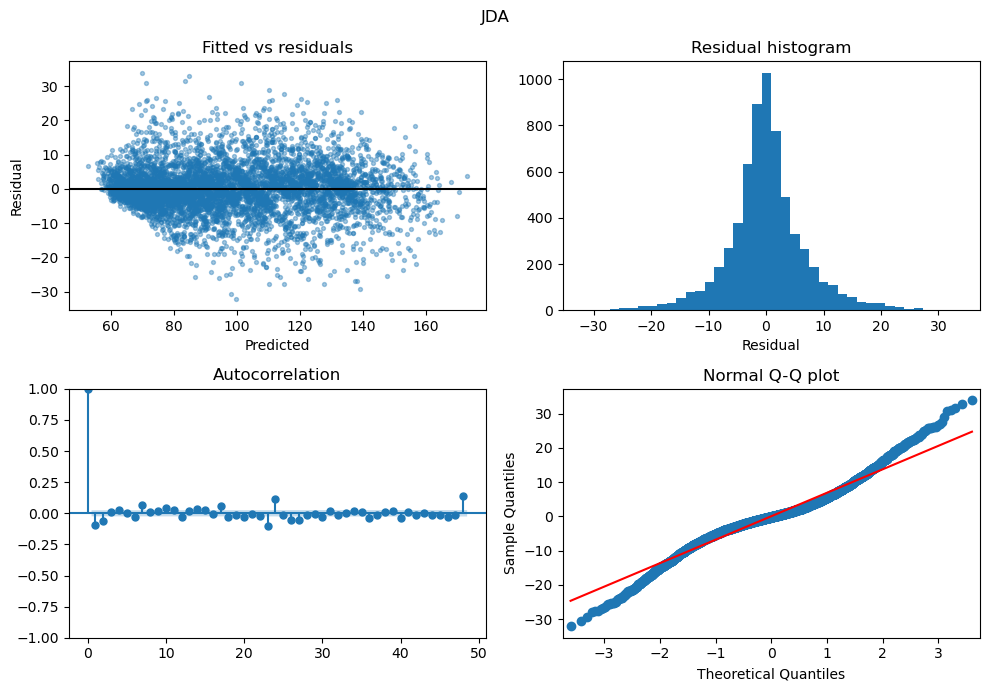


TDA: std_diu = 7.3437 kcfs
TDA test R²: 0.925


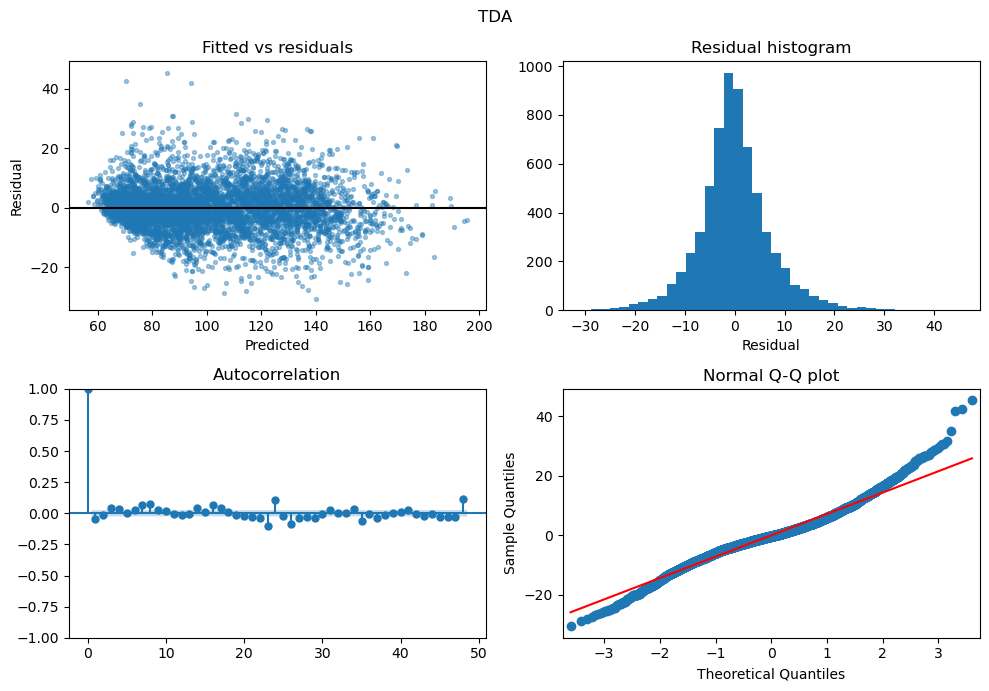


BON: std_diu = 4.5589 kcfs
BON test R²: 0.971


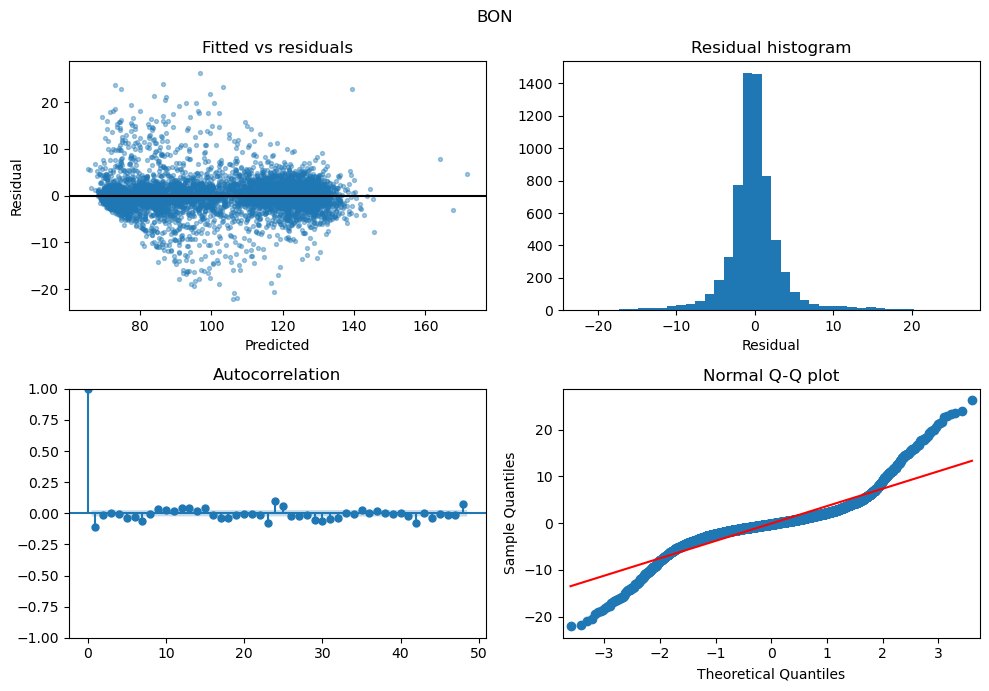

In [249]:
# Store conditional-mean models and predictions
mean_models = {}
train_results = {}
test_results = {}
std_diu = {}

for unit, (target, upstream, p, release_lags) in reach_map.items():

    # Fit regression using training data 
    mean_model, features = fit_mean_model(model_df, target, upstream, p, release_lags)

    mean_models[unit] = {"model": mean_model, "features": features}

    # Fit on training data for GARCH model training 
    train_results[unit] = one_step_predict(model_df, mean_model,target, upstream, train_years,  p, release_lags)

    # Test on training data, predicting one time step at a time 
    test_results[unit] = one_step_predict(model_df, mean_model, target, upstream, test_years, p, release_lags)
    
for unit in ["jda", "tda", "bon"]:
    
    # Estimate constant DIU uncertainty from training data only
    train_result = train_results[unit]
    train_residual = (train_result["actual"] - train_result["predicted"])
    std_diu[unit] = np.sqrt(np.mean(train_residual**2))

    residual = result["actual"] - result["predicted"]
    residual = residual - residual.mean()

    print(f"\n{unit.upper()}: "f"std_diu = {std_diu[unit]:.4f} kcfs")
    diagnose(test_results[unit], unit)

In [256]:
def mcn_predictions(years):
    d = model_df.copy()
    d["predicted"] = (d.groupby("season_year")["mcn_inflow_avg"].shift(1))

    d = d[d["season_year"].isin(years)].dropna(subset=["mcn_inflow_avg", "predicted"])

    return (
        d[["datetime", "season_year", "mcn_inflow_avg", "predicted"]]
        .rename(columns={"mcn_inflow_avg": "actual"})
        .set_index("datetime")
    )


train_results["mcn"] = mcn_predictions(train_years)
test_results["mcn"] = mcn_predictions(test_years)

mcn_error = (train_results["mcn"]["actual"]- train_results["mcn"]["predicted"])

std_diu["mcn"] = np.sqrt(np.mean(mcn_error**2))

In [261]:
std_diu["mcn"] # kcfs

9.811540922100674

MCN test R²: 0.906


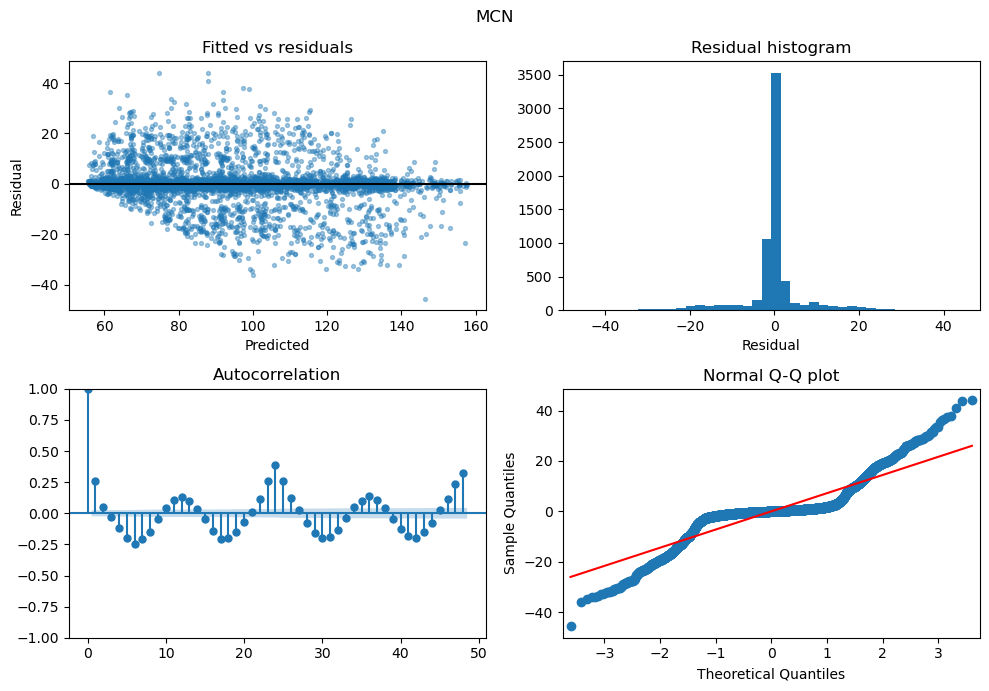

In [258]:
diagnose(test_results["mcn"], "mcn")

### Print Model Fit

In [251]:
# Print coeficients transformed back to real-world scale 
for unit, (target, upstream, p, release_lags) in reach_map.items():
    model, features = fit_mean_model(model_df, target, upstream, p, release_lags)

    scaler = model[0]
    ridge = model[-1]

    coef = ridge.coef_ / scaler.scale_
    intercept = ridge.intercept_ - coef @ scaler.mean_

    print(f"\n{unit.upper()}")
    print(pd.Series(
        [intercept, *coef],
        index=["intercept", *features],
    ))


JDA
intercept    1.196582
q_lag_1      1.103326
q_lag_2     -0.249067
q_lag_3     -0.015380
q_lag_4      0.002325
q_lag_5      0.002080
q_lag_6     -0.037717
q_lag_7     -0.031418
q_lag_8     -0.005535
q_lag_9      0.038902
q_lag_10     0.021133
q_lag_11     0.016580
q_lag_12     0.019855
q_lag_13    -0.015722
q_lag_14    -0.013222
q_lag_15    -0.031248
q_lag_16    -0.028910
q_lag_17     0.008013
q_lag_18     0.036447
q_lag_19     0.010977
q_lag_20     0.025355
q_lag_21    -0.016201
q_lag_22     0.030009
q_lag_23     0.151888
q_lag_24    -0.060597
r_lag_9      0.043528
r_lag_10    -0.001397
r_lag_11    -0.013410
dtype: float64

TDA
intercept    1.611301
q_lag_1      1.076942
q_lag_2     -0.220175
q_lag_3     -0.040796
q_lag_4      0.005002
q_lag_5     -0.015331
q_lag_6     -0.043333
q_lag_7     -0.022490
q_lag_8     -0.009405
q_lag_9      0.066695
q_lag_10     0.015401
q_lag_11     0.026705
q_lag_12    -0.011869
q_lag_13    -0.003455
q_lag_14    -0.015966
q_lag_15     0.010390
q_lag_1

### Calculate Error Correlation Matrix

In [152]:
error_df = pd.concat(
    {
        unit: result["actual"] - result["predicted"]
        for unit, result in test_results.items()
    },
    axis=1
).dropna()

R = error_df.corr()
R

,jda,tda,bon
jda,1.000000,0.089969,0.067978
tda,0.089969,1.000000,0.046381
bon,0.067978,0.046381,1.000000


# Residual Modeling

In [165]:
# 1. Prepare input data for GARCH Model 
def prepare_data(unit, results):
    
    target, upstream, _, release_lags = reach_map[unit]
    travel_lag = release_lags[len(release_lags) // 2] # select main lag term 

    # datetime 
    d = add_season_year(model_df).sort_values("datetime").copy()

    # calculate upstream ramps 
    d["ramp"] = d.groupby("season_year")[upstream].diff()

    # get lagged release
    d["release"] = d.groupby("season_year")[upstream].shift(travel_lag)

    # calculate lagged ramp
    d["ramp"] = d.groupby("season_year")["ramp"].shift(travel_lag).abs()

    d = d.set_index("datetime")

    # calculate  forecast errors 
    d["residual"] = results[unit]["actual"] - results[unit]["predicted"]

    # predictors
    needed = ["residual", "season_year", "release", "ramp"]

    return d[needed].dropna()

In [187]:
PERSISTENCE_CAP = 0.995

# 2. Fit Gaussian ARCH-X model
def fit_model(train):

    # Forecast errors in kcfs
    errors = train["residual"].to_numpy(dtype=float)

    # Variance used for the first observation of each season
    initial_variance = np.mean(errors**2)

    if not np.isfinite(initial_variance) or initial_variance <= 0:
        raise ValueError("Residual variance must be positive and finite.")

    # Identify the first observation of each season
    season = train["season_year"].to_numpy()
    reset = np.r_[True, season[1:] != season[:-1]]

    # Normalize release and ramp using training ranges
    x_ranges = {}
    X = []

    for col in ["release", "ramp"]:

        xmin = train[col].min()
        xrange = train[col].max() - xmin

        if not np.isfinite(xrange) or xrange <= 0:
            xrange = 1.0

        x = (
            train[col].to_numpy(dtype=float) - xmin
        ) / xrange

        X.append(x)
        x_ranges[col] = (xmin, xrange)

    X = np.column_stack(X)


    # Gaussian negative log-likelihood
    def nll(par):

        omega, alpha, gamma_u, gamma_r = par

        sigma2 = np.empty(len(errors))

        for t in range(len(errors)):

            if reset[t]:
                sigma2[t] = initial_variance

            else:
                sigma2[t] = (
                    omega
                    + alpha * errors[t - 1]**2
                    + gamma_u * X[t, 0]
                    + gamma_r * X[t, 1]
                )

            if not np.isfinite(sigma2[t]) or sigma2[t] <= 0:
                return 1e20

        loglik = -0.5 * (
            np.log(2.0 * np.pi)
            + np.log(sigma2)
            + errors**2 / sigma2
        )

        return -loglik[~reset].sum()


    # Starting parameter values
    starts = [
        [
            0.80 * initial_variance,  # omega
            0.10,                     # alpha
            0.05 * initial_variance,  # gamma release
            0.05 * initial_variance,  # gamma ramp
        ],
        [
            0.50 * initial_variance,
            0.25,
            0.10 * initial_variance,
            0.10 * initial_variance,
        ],
    ]

    # Parameter restrictions
    bounds = [
        (1e-8, None),             # omega > 0
        (0.0, PERSISTENCE_CAP),   # 0 <= alpha <= 0.995
        (0.0, None),              # gamma release >= 0
        (0.0, None),              # gamma ramp >= 0
    ]


    # Fit from both starting points
    fits = []

    for start in starts:

        fit = minimize(
            nll,
            start,
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter": 5000,
                "ftol": 1e-8,
            },
        )

        fits.append(fit)

    successful = [fit for fit in fits if fit.success]

    if not successful:
        messages = "; ".join(
            str(fit.message) for fit in fits
        )

        raise RuntimeError(
            f"ARCH-X estimation failed: {messages}"
        )

    best_fit = min(
        successful,
        key=lambda fit: fit.fun,
    )

    # ARCH-X estimates four parameters
    omega, alpha, gamma_u, gamma_r = best_fit.x

    # Keep beta = 0 so existing test code remains compatible
    parameters = np.array([
        omega,
        alpha,
        0.0,
        gamma_u,
        gamma_r,
    ])

    return {
        "garch": parameters,
        "x_ranges": x_ranges,
        "initial_variance": initial_variance,
        "converged": best_fit.success,
        "optimizer_message": best_fit.message,
        "negative_log_likelihood": best_fit.fun,
        "train_residual": errors,
    }

In [189]:
# 3. Apply the fitted Gaussian GARCH-X model to test data.
def test_model(test, model):

    # The forecast residual 
    errors = test["residual"].to_numpy(dtype=float)

    # Normalize release and ramp using the TRAINING-data ranges
    def normalize(column):
        minimum, value_range = model["x_ranges"][column]

        normalized = (test[column].to_numpy(dtype=float) - minimum) / value_range

        # Prevent extrapolation below the training minimum
        return np.maximum(normalized, 0.0)

    release = normalize("release")
    ramp = normalize("ramp")

    # Retrieve the five fitted Gaussian GARCH-X parameters
    omega, alpha, beta, gamma_u, gamma_r = model["garch"]

    # Identify the first observation of each seasonal year
    seasons = test["season_year"].to_numpy()
    reset = np.r_[True, seasons[1:] != seasons[:-1]]

    # Calculate the conditional variance recursively
    variance = np.empty(len(test))

    for t in range(len(test)):
        if reset[t]:
            # Restart using the training residual variance
            variance[t] = model["initial_variance"]
        else:
            variance[t] = (
                omega
                + alpha * errors[t - 1] ** 2
                + beta * variance[t - 1]
                + gamma_u * release[t]
                + gamma_r * ramp[t]
            )

    # Conditional standard deviation in kcfs
    sigma = np.sqrt(variance)

    # Standardized Gaussian residuals
    z = errors / sigma

    # Gaussian log-likelihood for each test observation
    log_likelihood = -0.5 * (
        np.log(2.0 * np.pi)
        + np.log(variance)
        + errors**2 / variance
    )

    # Add the uncertainty results to a copy of the test data
    output = test.copy()
    output["variance"] = variance
    output["sigma"] = sigma
    output["z"] = z
    output["reset"] = reset

    # Exclude seasonal reset observations (t = 1) because their variance is fixed rather than calculated from the fitted parameters
    mean_nll = -log_likelihood[~reset].mean()

    return output, mean_nll

In [197]:
from scipy.stats import norm

# 4. Fit and test models 
models = {}
test_outputs = {}
rows = []

for unit in ["jda", "tda", "bon"]:

    # Prepare training and test data
    train = prepare_data(unit, train_results)
    test = prepare_data(unit, test_results)

    # Fit Gaussian GARCH-X model
    model = fit_model(train)

    # Test Gaussian GARCH-X model
    output, test_nll = test_model(test, model)

    models[unit] = model
    test_outputs[unit] = output

    # Store paramemeters 
    omega, alpha, beta, gamma_u, gamma_r = model["garch"]

    # Exclude the first observation of each season
    valid = output.loc[~output["reset"]]
    z = valid["z"]

    # Calculate min max parameters 
    release_min, release_range = model["x_ranges"]["release"]
    ramp_min, ramp_range = model["x_ranges"]["ramp"]

    row = {
        "unit": unit,
        "omega": omega,
        "alpha": alpha,
        "beta": beta,
        "gamma_release": gamma_u,
        "gamma_ramp": gamma_r,
        "persistence": alpha + beta,
        "sigma_DIU": std_diu[unit],
        "release_min": release_min,
        "release_range": release_range,
        "ramp_min": ramp_min,
        "ramp_range": ramp_range,
        "test_NLL": test_nll,
        "converged": model["converged"],
    }

    # Calculate Gaussian interval coverage
    for level in [0.90, 0.95, 0.99]:

        critical_value = norm.ppf(
            (1 + level) / 2
        )

        row[f"coverage_{int(level * 100)}"] = (
            np.abs(z) <= critical_value
        ).mean()

    rows.append(row)


results_table = pd.DataFrame(rows)

display(results_table.round(4))

,unit,omega,alpha,beta,gamma_release,gamma_ramp,persistence,sigma_DIU,release_min,release_range,ramp_min,ramp_range,test_NLL,converged,coverage_90,coverage_95,coverage_99
0,jda,26.5990,0.1605,0.0,47.3650,30.6786,0.1605,7.0299,47.9,155.6,0.0,70.6,3.3482,True,0.9017,0.9323,0.9691
1,tda,25.2339,0.1576,0.0,62.8574,27.9373,0.1576,7.2824,50.8,165.4,0.0,57.1,3.3685,True,0.9051,0.9389,0.9753
2,bon,12.0440,0.2788,0.0,1.0294,30.6790,0.2788,4.2637,23.4,192.7,0.0,118.1,2.8223,True,0.9230,0.9410,0.9632


In [263]:
def prepare_mcn(results):
    d = results["mcn"].copy()
    d["residual"] = d["actual"] - d["predicted"]
    d["release"] = 0.0
    d["ramp"] = 0.0

    return d[[
        "residual",
        "season_year",
        "release",
        "ramp",
    ]]

In [265]:
mcn_train = prepare_mcn(train_results)
mcn_test = prepare_mcn(test_results)

models["mcn"] = fit_model(mcn_train)

# McNary has no upstream decision-dependent terms
models["mcn"]["garch"][3:] = 0.0

test_outputs["mcn"], mcn_test_nll = test_model(
    mcn_test,
    models["mcn"],
)

models["mcn"]["garch"]

array([73.83117077,  0.24758231,  0.        ,  0.        ,  0.        ])

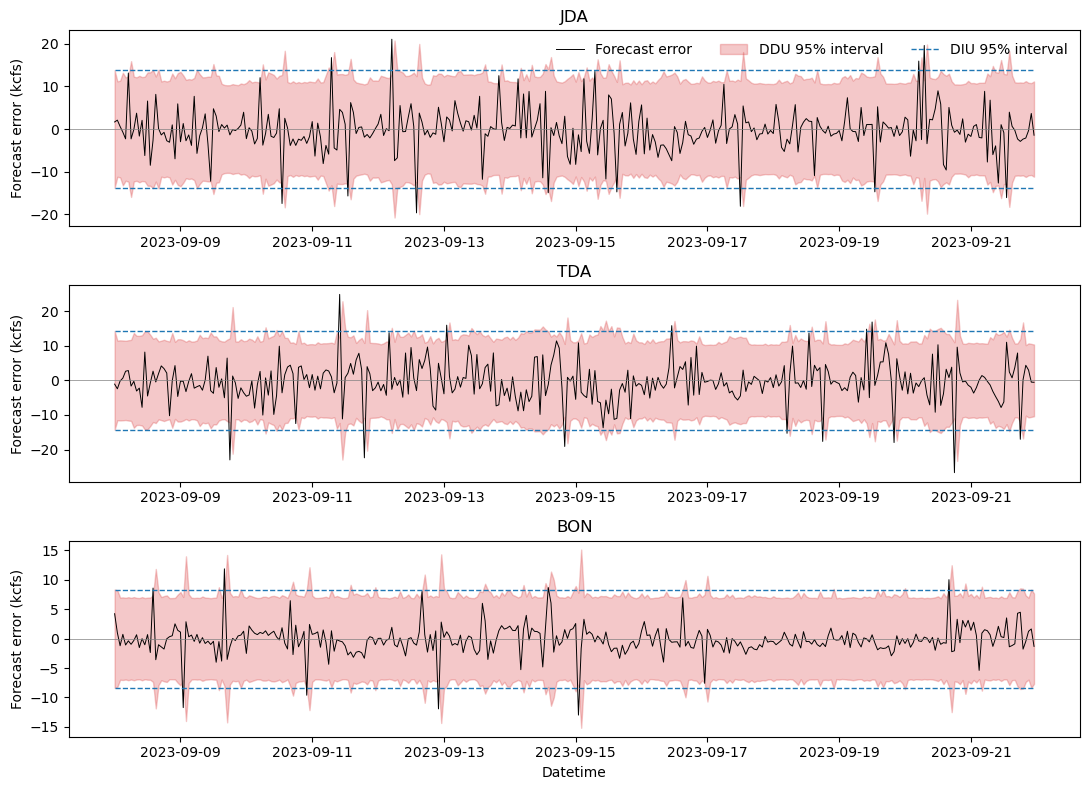

In [223]:
# 5. Plot Results

fig, ax = plt.subplots(3, 1, figsize=(11, 8))
q95 = norm.ppf(0.975)

for i, unit in enumerate(["jda", "tda", "bon"]):
    d = test_outputs[unit].copy()

    first_season = d["season_year"].iloc[0]
    d = d[d["season_year"] == 2023].iloc[:24 * 14]

    ddu_bound = q95 * d["sigma"]
    diu_bound = q95 * std_diu[unit]

    ax[i].plot(d.index, d["residual"], color="black", linewidth=0.7, label="Forecast error")

    ax[i].fill_between(
        d.index, -ddu_bound, ddu_bound,
        color="tab:red", alpha=0.25, label="DDU 95% interval"
    )

    ax[i].plot(
        d.index, np.full(len(d), diu_bound), "--",
        color="tab:blue", linewidth=1, label="DIU 95% interval"
    )

    ax[i].plot(
        d.index, np.full(len(d), -diu_bound), "--",
        color="tab:blue", linewidth=1
    )

    ax[i].axhline(0, color="gray", linewidth=0.5)
    ax[i].set_title(unit.upper())
    ax[i].set_ylabel("Forecast error (kcfs)")

ax[-1].set_xlabel("Datetime")
ax[0].legend(ncol=3, frameon=False)

plt.tight_layout()
plt.show()

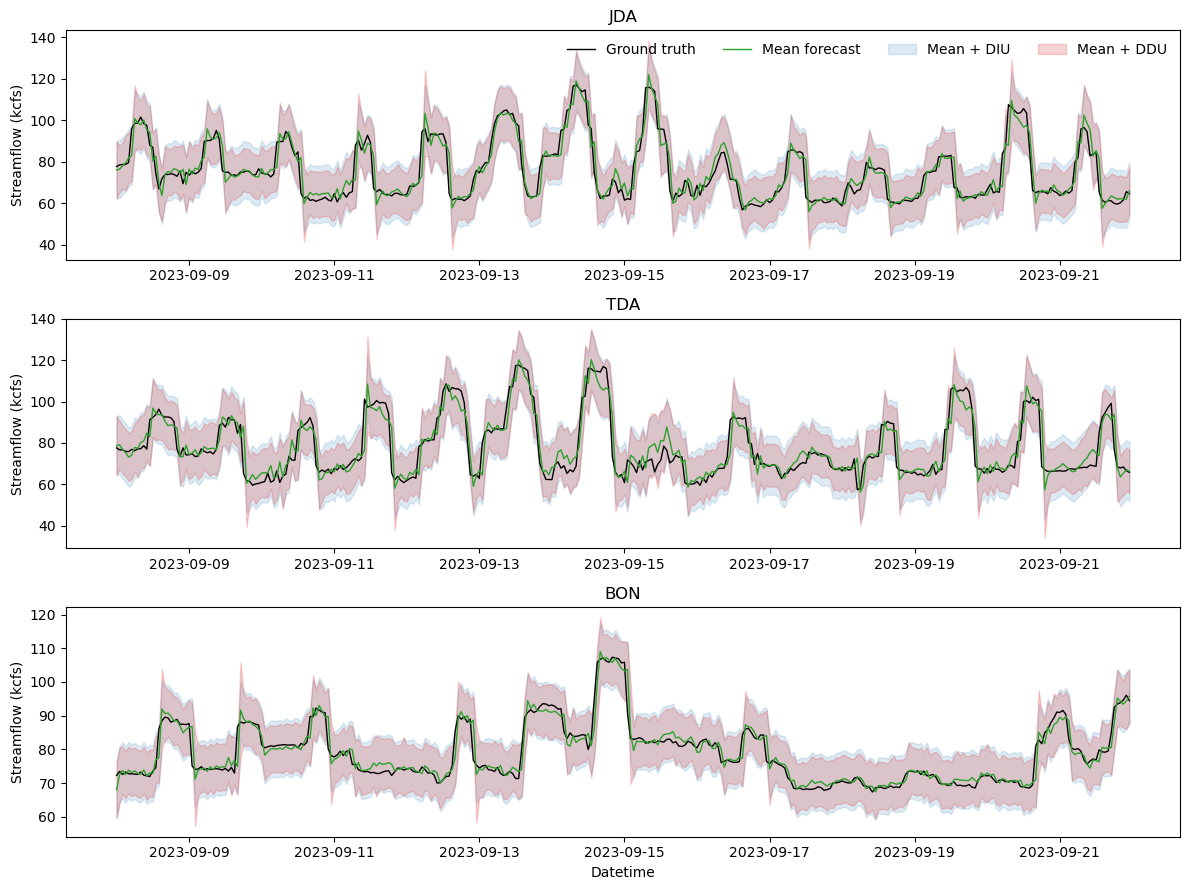

In [221]:
# Plot streamflow forecasts under DIU and DDU

fig, ax = plt.subplots(3, 1, figsize=(12, 9))
q95 = norm.ppf(0.975)

for i, unit in enumerate(["jda", "tda", "bon"]):
    d = test_results[unit][["actual", "predicted", "season_year"]].join(
        test_outputs[unit][["sigma"]], how="inner"
    )

    first_season = d["season_year"].iloc[0]
    d = d[d["season_year"] == 2023].iloc[:24 * 14]

    diu_lower = np.maximum(0, d["predicted"] - q95 * std_diu[unit])
    diu_upper = d["predicted"] + q95 * std_diu[unit]

    ddu_lower = np.maximum(0, d["predicted"] - q95 * d["sigma"])
    ddu_upper = d["predicted"] + q95 * d["sigma"]

    ax[i].plot(d.index, d["actual"], color="black", linewidth=1, label="Ground truth")
    ax[i].plot(d.index, d["predicted"], color="tab:green", linewidth=1, label="Mean forecast")

    ax[i].fill_between(
        d.index, diu_lower, diu_upper,
        color="tab:blue", alpha=0.15, label="Mean + DIU"
    )

    ax[i].fill_between(
        d.index, ddu_lower, ddu_upper,
        color="tab:red", alpha=0.20, label="Mean + DDU"
    )

    ax[i].set_title(unit.upper())
    ax[i].set_ylabel("Streamflow (kcfs)")

ax[-1].set_xlabel("Datetime")
ax[0].legend(ncol=4, frameon=False)

plt.tight_layout()
plt.show()

In [211]:
# Compare DIU and DDU interval performance

rows = []
q95 = norm.ppf(0.975)
alpha = 0.05

for unit in ["jda", "tda", "bon"]:
    d = test_results[unit][["actual", "predicted"]].join(
        test_outputs[unit][["sigma"]], how="inner"
    )

    y = d["actual"]
    mean = d["predicted"]

    diu_lower = np.maximum(0, mean - q95 * std_diu[unit])
    diu_upper = mean + q95 * std_diu[unit]

    ddu_lower = np.maximum(0, mean - q95 * d["sigma"])
    ddu_upper = mean + q95 * d["sigma"]

    for method, lower, upper in [
        ("DIU", diu_lower, diu_upper),
        ("DDU", ddu_lower, ddu_upper)
    ]:
        coverage = ((y >= lower) & (y <= upper)).mean()
        width = (upper - lower).mean()

        interval_score = (
            upper - lower
            + (2 / alpha) * np.maximum(lower - y, 0)
            + (2 / alpha) * np.maximum(y - upper, 0)
        ).mean()

        rows.append({
            "unit": unit.upper(),
            "method": method,
            "coverage_95": coverage,
            "mean_width": width,
            "interval_score": interval_score,
        })

comparison = pd.DataFrame(rows)
display(comparison.round(4))

,unit,method,coverage_95,mean_width,interval_score
0,JDA,DIU,0.9302,27.5565,40.6552
1,JDA,DDU,0.9323,27.3501,40.3021
2,TDA,DIU,0.9376,28.5466,40.6771
3,TDA,DDU,0.9389,27.9726,39.6057
4,BON,DIU,0.9383,16.7134,28.4951
5,BON,DDU,0.9411,16.3556,27.3909


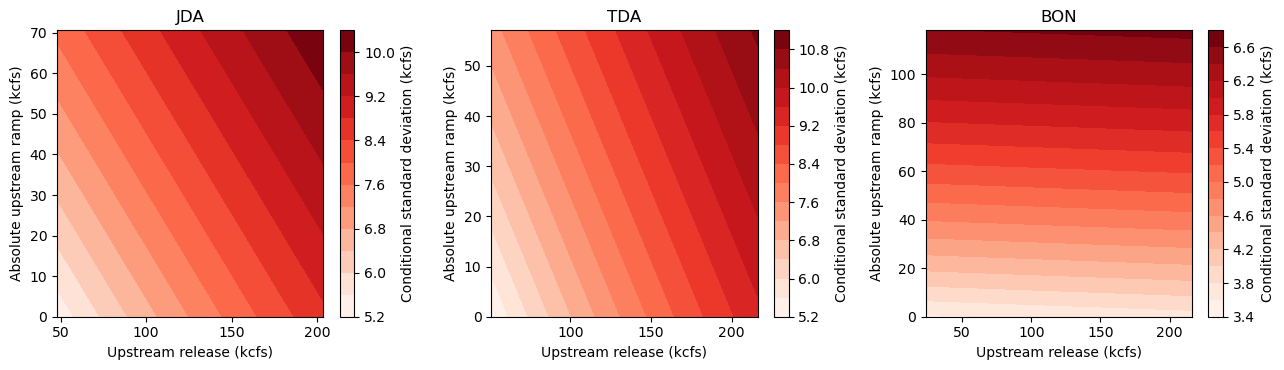

In [217]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))

for i, unit in enumerate(["jda", "tda", "bon"]):
    model = models[unit]
    d = test_outputs[unit]

    omega, alpha, _, gamma_u, gamma_r = model["garch"]

    release_min, release_range = model["x_ranges"]["release"]
    ramp_min, ramp_range = model["x_ranges"]["ramp"]

    release = np.linspace(release_min, release_min + release_range, 60)
    ramp = np.linspace(ramp_min, ramp_min + ramp_range, 60)

    release_grid, ramp_grid = np.meshgrid(release, ramp)

    release_scaled = (release_grid - release_min) / release_range
    ramp_scaled = (ramp_grid - ramp_min) / ramp_range

    # Hold the previous squared residual at its median value
    error2_reference = (d["residual"]**2).median()

    sigma = np.sqrt(
        omega
        + alpha * error2_reference
        + gamma_u * release_scaled
        + gamma_r * ramp_scaled
    )

    contour = ax[i].contourf(
        release_grid, ramp_grid, sigma,
        levels=15, cmap="Reds"
    )

    fig.colorbar(
        contour, ax=ax[i],
        label="Conditional standard deviation (kcfs)"
    )

    ax[i].set(
        title=unit.upper(),
        xlabel="Upstream release (kcfs)",
        ylabel="Absolute upstream ramp (kcfs)"
    )

plt.tight_layout()
plt.show()

In [267]:
unit_order = ["mcn", "jda", "tda", "bon"]

error_df = pd.concat(
    {
        unit: (
            train_results[unit]["actual"]
            - train_results[unit]["predicted"]
        )
        for unit in unit_order
    },
    axis=1,
).dropna()

R = error_df.corr()
display(R.round(6))

,mcn,jda,tda,bon
mcn,1.000000,0.092792,0.013465,0.025220
jda,0.092792,1.000000,0.159639,0.090705
tda,0.013465,0.159639,1.000000,0.062000
bon,0.025220,0.090705,0.062000,1.000000
